# Final Comparison and Model Selection

This notebook brings together the full model comparison for the project.

The notebook covers:

1. comparison framework  
2. prediction metric comparison across model families  
3. strategy metric comparison across model families  
4. transaction-cost comparison  
5. model-development summary  
6. final model selection and interpretation  

The objective is to provide a clear and reproducible final comparison across all benchmark, linear, tree-based, and neural approaches.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_multi_series,
    plot_metric_bar,
    plot_grouped_metric_bars,
)

In [3]:
NOTEBOOK_NAME = "notebook08"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook08
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook08


In [4]:
def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> pd.DataFrame:
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")
    return df


def fig_path(filename: str) -> str:
    return str(FIGURES_DIR / filename)

## 1. Comparison framework

The final comparison includes the following model families:

- baseline momentum benchmark  
- Ridge regression  
- Random Forest  
- XGBoost  
- neural models (MLP and LSTM)  

The comparison is based on two complementary perspectives:

1. **prediction quality**
   - MAE
   - RMSE
   - R²
   - Directional Accuracy
   - Spearman rank correlation
   - Top-k hit rate

2. **portfolio usefulness**
   - cumulative return
   - annualized return
   - annualized volatility
   - max drawdown
   - Sharpe ratio
   - average turnover

In [5]:
def load_json(path: Path) -> dict:
    with open(path, "r") as f:
        return json.load(f)


def load_equity(path: Path) -> pd.Series:
    s = pd.read_csv(path, index_col=0).squeeze("columns")
    s.index = pd.to_datetime(s.index)
    return s

In [6]:
dirs = {
    "Baseline Momentum": PROJECT_ROOT / "experiments" / "results" / "exp01_baseline_monthly",
    "Ridge daily": PROJECT_ROOT / "experiments" / "results" / "exp02_linear_ridge_daily",
    "Ridge daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp02_linear_ridge_daily_ohlcv",
    "RF daily": PROJECT_ROOT / "experiments" / "results" / "exp04_random_forest_rolling_daily",
    "RF daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp04_random_forest_rolling_daily_ohlcv",
    "XGBoost daily": PROJECT_ROOT / "experiments" / "results" / "exp03_xgboost_rolling_daily",
    "XGBoost daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp03_xgboost_rolling_daily_ohlcv",
    "MLP daily": PROJECT_ROOT / "experiments" / "results" / "exp05_nn_mlp_daily",
    "MLP daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp05_nn_mlp_daily_ohlcv",
    "LSTM": PROJECT_ROOT / "experiments" / "results" / "exp06_lstm_daily",
}

dirs

{'Baseline Momentum': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp01_baseline_monthly'),
 'Ridge daily': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp02_linear_ridge_daily'),
 'Ridge daily_ohlcv': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp02_linear_ridge_daily_ohlcv'),
 'RF daily': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp04_random_forest_rolling_daily'),
 'RF daily_ohlcv': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp04_random_forest_rolling_daily_ohlcv'),
 'XGBoost daily': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp03_xgboost_rolling_daily'),
 'XGBoost daily_ohlcv': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stabili

In [7]:
for name, d in dirs.items():
    print(f"\n{name}")
    print("dir:", d)
    for fn in ["metrics_test_2025.json", "metrics_test_2025_with_costs.json", "equity_test_2025.csv"]:
        print(f"{fn}: {(d / fn).exists()}")


Baseline Momentum
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp01_baseline_monthly
metrics_test_2025.json: True
metrics_test_2025_with_costs.json: True
equity_test_2025.csv: True

Ridge daily
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp02_linear_ridge_daily
metrics_test_2025.json: True
metrics_test_2025_with_costs.json: True
equity_test_2025.csv: True

Ridge daily_ohlcv
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp02_linear_ridge_daily_ohlcv
metrics_test_2025.json: True
metrics_test_2025_with_costs.json: True
equity_test_2025.csv: True

RF daily
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp04_random_forest_rolling_daily
metrics_test_2025.json: True
metrics_test_2025_with_costs.json: True
equity_test_2025.csv: True

RF daily_ohlcv
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-

In [8]:
baseline_metrics_test = load_json(dirs["Baseline Momentum"] / "metrics_test_2025.json")
baseline_metrics_test_costs = load_json(dirs["Baseline Momentum"] / "metrics_test_2025_with_costs.json")
baseline_equity_test = load_equity(dirs["Baseline Momentum"] / "equity_test_2025.csv")

In [9]:
def load_model_bundle(exp_dir: Path) -> dict:
    bundle = {
        "metrics_test": load_json(exp_dir / "metrics_test_2025.json"),
        "metrics_test_costs": load_json(exp_dir / "metrics_test_2025_with_costs.json"),
        "equity_test": load_equity(exp_dir / "equity_test_2025.csv"),
    }

    pred_path = exp_dir / "prediction_metrics.json"
    if pred_path.exists():
        bundle["prediction_metrics"] = load_json(pred_path)
    else:
        bundle["prediction_metrics"] = None

    return bundle

In [10]:
model_names = [k for k in dirs.keys() if k != "Baseline Momentum"]
bundles = {name: load_model_bundle(dirs[name]) for name in model_names}
bundles.keys()

dict_keys(['Ridge daily', 'Ridge daily_ohlcv', 'RF daily', 'RF daily_ohlcv', 'XGBoost daily', 'XGBoost daily_ohlcv', 'MLP daily', 'MLP daily_ohlcv', 'LSTM'])

In [11]:
prediction_rows = []

for name, bundle in bundles.items():
    pm = bundle["prediction_metrics"]
    if pm is None:
        continue

    # Ridge / MLP / LSTM style
    if "test_2025" in pm:
        row = {
            "model": name,
            "MAE": pm["test_2025"]["regression"]["MAE"],
            "RMSE": pm["test_2025"]["regression"]["RMSE"],
            "R2": pm["test_2025"]["regression"]["R2"],
            "Directional_Accuracy": pm["test_2025"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["test_2025"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["test_2025"]["ranking"]["Months_evaluated"],
        }
        prediction_rows.append(row)

    # RF / XGB rolling style
    elif "test_2025_rolling_fit" in pm:
        row = {
            "model": name,
            "MAE": pm["test_2025_rolling_fit"]["regression"]["MAE"],
            "RMSE": pm["test_2025_rolling_fit"]["regression"]["RMSE"],
            "R2": pm["test_2025_rolling_fit"]["regression"]["R2"],
            "Directional_Accuracy": pm["test_2025_rolling_fit"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["test_2025_rolling_fit"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["test_2025_rolling_fit"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["test_2025_rolling_fit"]["ranking"]["Months_evaluated"],
        }
        prediction_rows.append(row)

prediction_comparison = save_table(
    pd.DataFrame(prediction_rows),
    "final_prediction_metrics_comparison.csv",
    index=False,
)
prediction_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook08\final_prediction_metrics_comparison.csv


,model,MAE,RMSE,R2,Directional_Accuracy,SpearmanRankCorr_mean,TopKHitRate_mean,Months_evaluated
0,Ridge daily,0.054522,0.073360,0.017624,0.554688,0.042863,0.301435,11
1,Ridge daily_ohlcv,0.054716,0.073867,0.004009,0.561523,0.048692,0.272727,11
2,RF daily,0.054756,0.073859,0.004201,0.563477,0.051451,0.363636,11
3,RF daily_ohlcv,0.054680,0.073823,0.005175,0.565430,0.081832,0.373206,11
4,XGBoost daily,0.055150,0.073978,0.001008,0.536133,0.055333,0.320574,11
5,XGBoost daily_ohlcv,0.055223,0.074440,-0.011523,0.554688,0.037959,0.296651,11
6,MLP daily,0.054951,0.074401,-0.010457,0.548828,0.081893,0.306220,11
7,MLP daily_ohlcv,0.054951,0.074368,-0.009555,0.572266,-0.042016,0.248804,11
8,LSTM,0.054757,0.074340,-0.001352,0.551485,0.021652,0.196704,11


In [12]:
strategy_rows = [
    {"model": "Baseline Momentum", **baseline_metrics_test}
]

for name, bundle in bundles.items():
    row = {"model": name}
    row.update(bundle["metrics_test"])
    strategy_rows.append(row)

strategy_comparison = save_table(
    pd.DataFrame(strategy_rows),
    "final_strategy_metrics_comparison.csv",
    index=False,
)
strategy_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook08\final_strategy_metrics_comparison.csv


,model,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,Baseline Momentum,0.380870,0.380870,0.130713,-0.068207,2.562590,0.137500,0.125000,0.350000
1,Ridge daily,0.217607,0.217607,0.155976,-0.061110,1.341890,0.425837,0.473684,0.578947
2,Ridge daily_ohlcv,0.160716,0.160716,0.161868,-0.072571,0.999271,0.454545,0.473684,0.578947
3,RF daily,0.357411,0.357411,0.142758,-0.037387,2.230756,0.334928,0.368421,0.578947
4,RF daily_ohlcv,0.383442,0.383442,0.145716,-0.045831,2.322132,0.301435,0.315789,0.473684
5,XGBoost daily,0.306814,0.306814,0.133432,-0.045293,2.087148,0.488038,0.526316,0.684211
6,XGBoost daily_ohlcv,0.278509,0.278509,0.122549,-0.050368,2.080711,0.483254,0.526316,0.684211
7,MLP daily,0.290920,0.290920,0.135754,-0.043890,1.961135,0.449761,0.473684,0.631579
8,MLP daily_ohlcv,0.141031,0.141031,0.140191,-0.079659,1.009288,0.550239,0.578947,0.736842
9,LSTM,0.169316,0.169316,0.088544,-0.039112,1.818267,0.672727,0.700000,0.900000


In [13]:
cost_rows = []

for cost_name, metrics in baseline_metrics_test_costs.items():
    row = {"model": "Baseline Momentum", "cost_scenario": cost_name}
    row.update(metrics)
    cost_rows.append(row)

for name, bundle in bundles.items():
    for cost_name, metrics in bundle["metrics_test_costs"].items():
        row = {"model": name, "cost_scenario": cost_name}
        row.update(metrics)
        cost_rows.append(row)

cost_comparison = save_table(
    pd.DataFrame(cost_rows),
    "final_cost_adjusted_comparison.csv",
    index=False,
)
cost_comparison

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook08\final_cost_adjusted_comparison.csv


,model,cost_scenario,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,Baseline Momentum,cost_0bps,0.380870,0.380870,0.130713,-0.068207,2.562590,0.137500,0.125000,0.350000
1,Baseline Momentum,cost_10bps,0.378629,0.378629,0.130846,-0.068557,2.547364,0.137500,0.125000,0.350000
2,Baseline Momentum,cost_20bps,0.376391,0.376391,0.130980,-0.068907,2.532157,0.137500,0.125000,0.350000
3,Ridge daily,cost_0bps,0.217607,0.217607,0.155976,-0.061110,1.341890,0.425837,0.473684,0.578947
4,Ridge daily,cost_10bps,0.212008,0.212008,0.155939,-0.062340,1.312170,0.425837,0.473684,0.578947
5,Ridge daily,cost_20bps,0.206432,0.206432,0.155904,-0.063806,1.282412,0.425837,0.473684,0.578947
6,Ridge daily_ohlcv,cost_0bps,0.160716,0.160716,0.161868,-0.072571,0.999271,0.454545,0.473684,0.578947
7,Ridge daily_ohlcv,cost_10bps,0.155003,0.155003,0.161792,-0.073097,0.968834,0.454545,0.473684,0.578947
8,Ridge daily_ohlcv,cost_20bps,0.149314,0.149314,0.161720,-0.073624,0.938351,0.454545,0.473684,0.578947
9,RF daily,cost_0bps,0.357411,0.357411,0.142758,-0.037387,2.230756,0.334928,0.368421,0.578947


In [14]:
model_order = [
    "Baseline Momentum",
    "Ridge daily",
    "Ridge daily_ohlcv",
    "RF daily",
    "RF daily_ohlcv",
    "XGBoost daily",
    "XGBoost daily_ohlcv",
    "MLP daily",
    "MLP daily_ohlcv",
    "LSTM",
]

In [15]:
final_color_map = {
    "Baseline Momentum": get_model_color("baseline"),
    "Ridge daily": get_model_color("ridge"),
    "Ridge daily_ohlcv": "#9C755F",
    "RF daily": get_model_color("random_forest"),
    "RF daily_ohlcv": "#8C564B",
    "XGBoost daily": get_model_color("xgboost"),
    "XGBoost daily_ohlcv": "#C5B0D5",
    "MLP daily": get_model_color("mlp"),
    "MLP daily_ohlcv": "#C49C94",
    "LSTM": get_model_color("lstm"),
}
final_color_map

{'Baseline Momentum': '#595959',
 'Ridge daily': '#4E79A7',
 'Ridge daily_ohlcv': '#9C755F',
 'RF daily': '#F28E2B',
 'RF daily_ohlcv': '#8C564B',
 'XGBoost daily': '#B07AA1',
 'XGBoost daily_ohlcv': '#C5B0D5',
 'MLP daily': '#9C755F',
 'MLP daily_ohlcv': '#C49C94',
 'LSTM': '#76B7B2'}

In [16]:
pred_plot_df = prediction_comparison.set_index("model").reindex([m for m in model_order if m in prediction_comparison["model"].values])

pred_metric_plot_df = pd.DataFrame(
    {
        "R2": pred_plot_df["R2"],
        "Spearman": pred_plot_df["SpearmanRankCorr_mean"],
        "TopK": pred_plot_df["TopKHitRate_mean"],
    }
).T

pred_metric_plot_df

model,Ridge daily,Ridge daily_ohlcv,RF daily,RF daily_ohlcv,XGBoost daily,XGBoost daily_ohlcv,MLP daily,MLP daily_ohlcv,LSTM
R2,0.017624,0.004009,0.004201,0.005175,0.001008,-0.011523,-0.010457,-0.009555,-0.001352
Spearman,0.042863,0.048692,0.051451,0.081832,0.055333,0.037959,0.081893,-0.042016,0.021652
TopK,0.301435,0.272727,0.363636,0.373206,0.320574,0.296651,0.306220,0.248804,0.196704


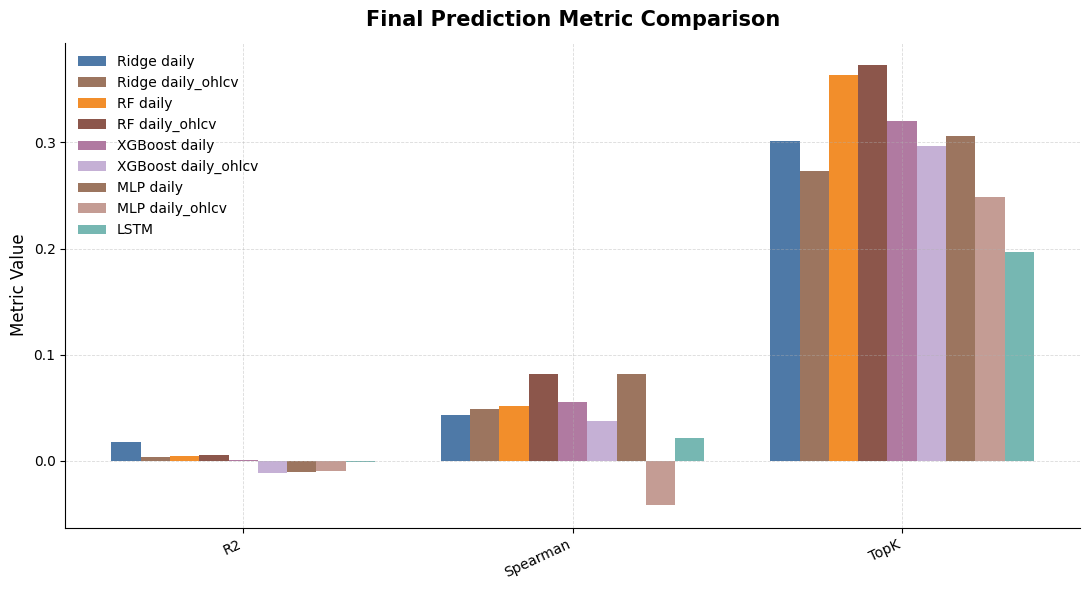

In [17]:
plot_grouped_metric_bars(
    metric_df=pred_metric_plot_df,
    title="Final Prediction Metric Comparison",
    ylabel="Metric Value",
    color_map=final_color_map,
    save_path=fig_path("final_prediction_metric_comparison.png"),
    show=True,
)

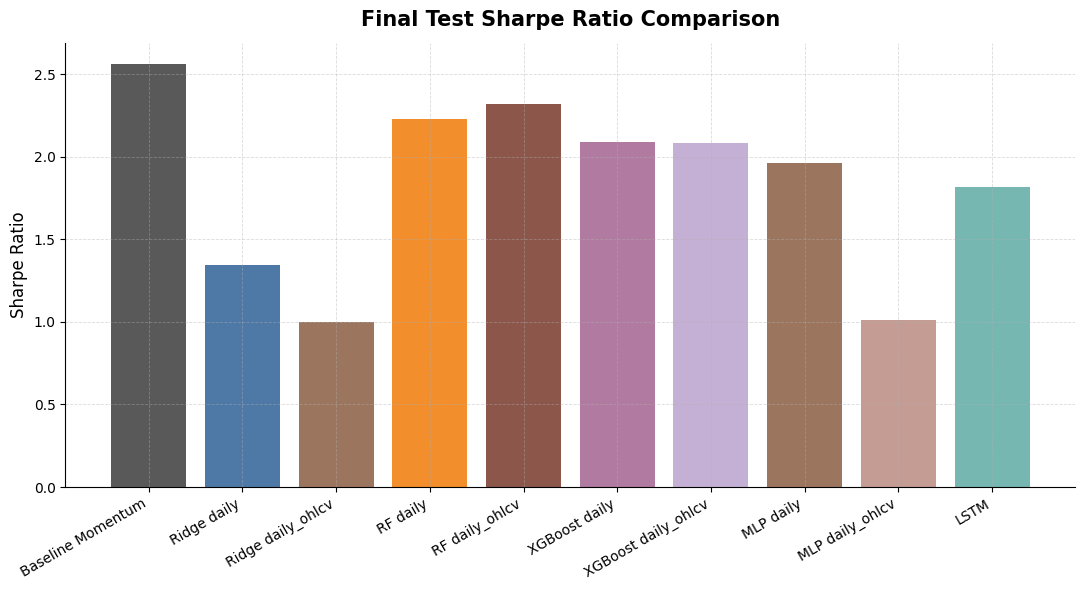

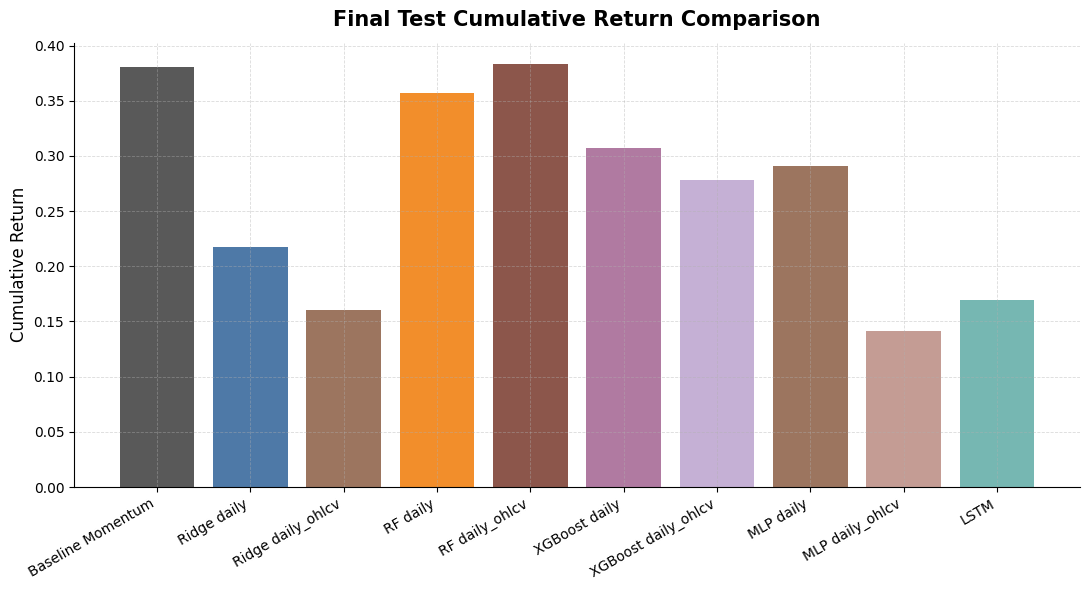

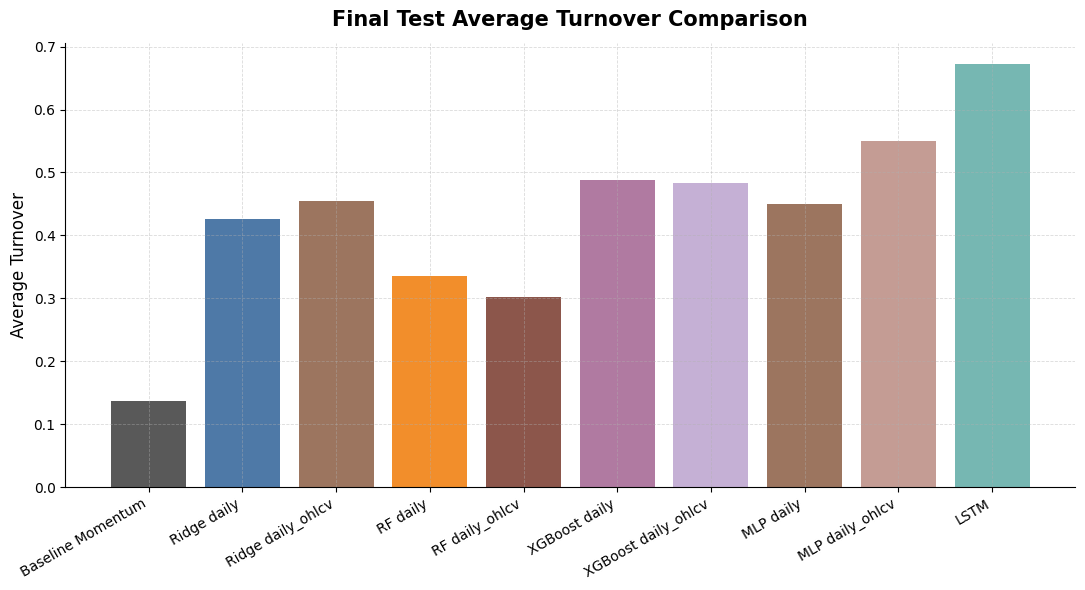

In [18]:
strategy_plot_df = strategy_comparison.set_index("model").reindex(model_order)

plot_metric_bar(
    strategy_plot_df["sharpe_ratio"],
    title="Final Test Sharpe Ratio Comparison",
    ylabel="Sharpe Ratio",
    color_map=final_color_map,
    save_path=fig_path("final_test_sharpe_comparison.png"),
    show=True,
)

plot_metric_bar(
    strategy_plot_df["cumulative_return"],
    title="Final Test Cumulative Return Comparison",
    ylabel="Cumulative Return",
    color_map=final_color_map,
    save_path=fig_path("final_test_cumulative_return_comparison.png"),
    show=True,
)

plot_metric_bar(
    strategy_plot_df["avg_turnover"],
    title="Final Test Average Turnover Comparison",
    ylabel="Average Turnover",
    color_map=final_color_map,
    save_path=fig_path("final_test_turnover_comparison.png"),
    show=True,
)

## 2. Test equity comparison

The plot below compares the out-of-sample 2025 equity curves for the main model variants.

In [19]:
equity_map = {
    "Baseline Momentum": baseline_equity_test,
}

for name, bundle in bundles.items():
    equity_map[name] = bundle["equity_test"]

selected_equity_order = [
    "Baseline Momentum",
    "Ridge daily_ohlcv",
    "RF daily",
    "RF daily_ohlcv",
    "XGBoost daily",
    "XGBoost daily_ohlcv",
    "LSTM",
]

selected_equity_map = {k: equity_map[k] for k in selected_equity_order if k in equity_map}
selected_equity_map.keys()

dict_keys(['Baseline Momentum', 'Ridge daily_ohlcv', 'RF daily', 'RF daily_ohlcv', 'XGBoost daily', 'XGBoost daily_ohlcv', 'LSTM'])

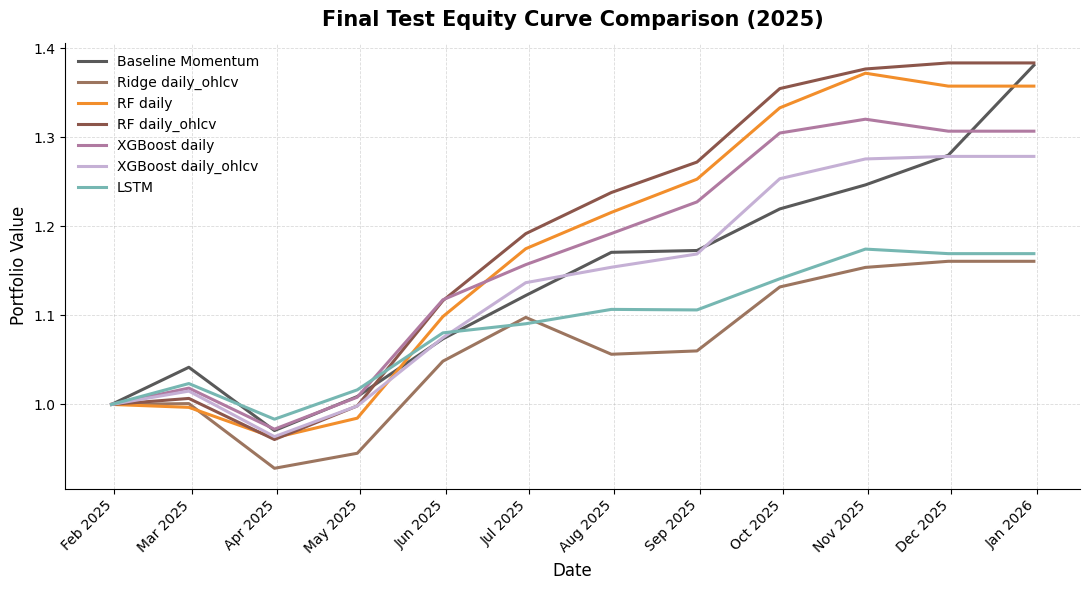

In [20]:
plot_multi_series(
    series_map=selected_equity_map,
    title="Final Test Equity Curve Comparison (2025)",
    ylabel="Portfolio Value",
    color_map=final_color_map,
    save_path=fig_path("final_test_equity_curve_comparison.png"),
    show=True,
)

In [21]:
cost_20bps = cost_comparison[cost_comparison["cost_scenario"] == "cost_20bps"].set_index("model").reindex(model_order)
cost_20bps[["cumulative_return", "sharpe_ratio"]]

,cumulative_return,sharpe_ratio
model,,
Baseline Momentum,0.376391,2.532157
Ridge daily,0.206432,1.282412
Ridge daily_ohlcv,0.149314,0.938351
RF daily,0.347634,2.174438
RF daily_ohlcv,0.374511,2.274708
XGBoost daily,0.293174,2.009352
XGBoost daily_ohlcv,0.265320,2.002948
MLP daily,0.278536,1.895408
MLP daily_ohlcv,0.127450,0.923833


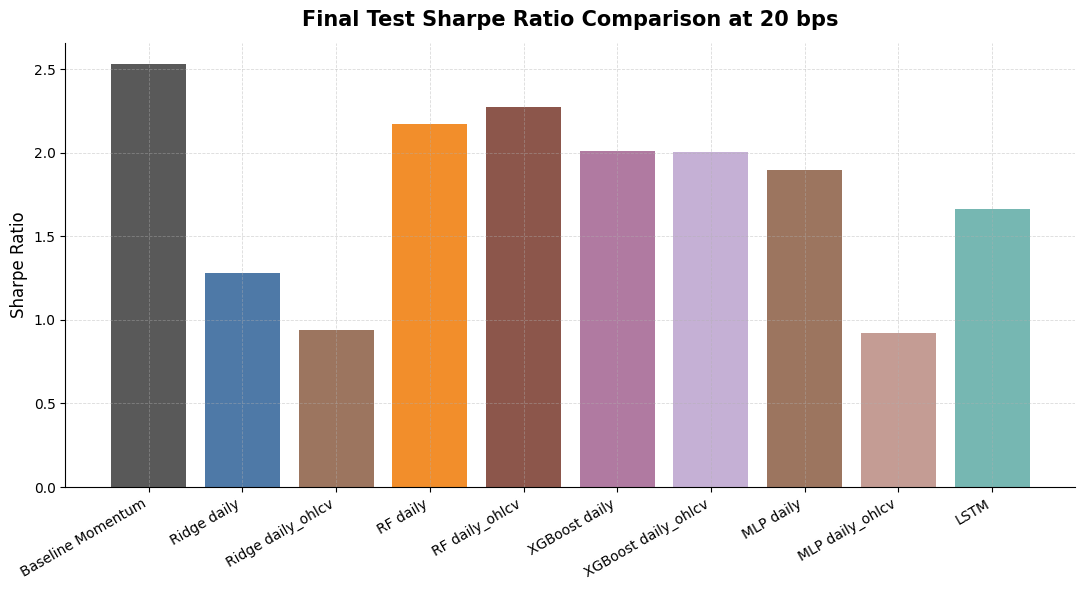

In [22]:
plot_metric_bar(
    cost_20bps["sharpe_ratio"],
    title="Final Test Sharpe Ratio Comparison at 20 bps",
    ylabel="Sharpe Ratio",
    color_map=final_color_map,
    save_path=fig_path("final_test_sharpe_20bps_comparison.png"),
    show=True,
)

## 3. Model-development summary

The model-development process proceeded in stages:

1. baseline momentum benchmark  
2. linear Ridge models  
3. Random Forest tabular models  
4. XGBoost boosted-tree models  
5. neural models (MLP and LSTM)  
6. feature-space extension from `daily` to `daily_ohlcv`  
7. tuning and robustness checks  

The main empirical finding is that stronger in-sample fit did not necessarily produce the best out-of-sample ranking and portfolio performance.

In [23]:
development_summary = save_table(
    pd.DataFrame(
        {
            "stage": [
                "Baseline momentum",
                "Ridge models",
                "Random Forest models",
                "XGBoost models",
                "Neural models",
                "OHLCV feature extension",
                "Tuning studies",
            ],
            "main_finding": [
                "Provided a transparent non-ML benchmark",
                "Established the first supervised-learning baseline family",
                "Delivered the strongest overall out-of-sample results",
                "Fit more strongly in-sample but generalized less well than the best RF",
                "Did not outperform the final RF model despite additional flexibility",
                "Helped the final RF model most clearly in ranking and portfolio construction",
                "Improved understanding of model complexity trade-offs but did not overturn the final RF selection",
            ],
        }
    ),
    "model_development_summary.csv",
    index=False,
)
development_summary

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook08\model_development_summary.csv


,stage,main_finding
0,Baseline momentum,Provided a transparent non-ML benchmark
1,Ridge models,Established the first supervised-learning base...
2,Random Forest models,Delivered the strongest overall out-of-sample ...
3,XGBoost models,Fit more strongly in-sample but generalized le...
4,Neural models,Did not outperform the final RF model despite ...
5,OHLCV feature extension,Helped the final RF model most clearly in rank...
6,Tuning studies,Improved understanding of model complexity tra...


In [24]:
final_selected_model = save_table(
    pd.DataFrame(
        {
            "selection_item": [
                "final_model",
                "feature_source",
                "training_scheme",
                "selection_rule",
                "reason_1",
                "reason_2",
                "reason_3",
                "reason_4",
            ],
            "value": [
                "Random Forest",
                "daily_ohlcv",
                "rolling",
                "top 20% equal-weight portfolio",
                "Best overall out-of-sample Sharpe ratio among the main competitive model family",
                "Best balance of ranking quality and portfolio performance",
                "Improved turnover behavior relative to several alternatives",
                "More reliable out-of-sample generalization than XGBoost and neural models",
            ],
        }
    ),
    "final_selected_model_summary.csv",
    index=False,
)
final_selected_model

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook08\final_selected_model_summary.csv


,selection_item,value
0,final_model,Random Forest
1,feature_source,daily_ohlcv
2,training_scheme,rolling
3,selection_rule,top 20% equal-weight portfolio
4,reason_1,Best overall out-of-sample Sharpe ratio among ...
5,reason_2,Best balance of ranking quality and portfolio ...
6,reason_3,Improved turnover behavior relative to several...
7,reason_4,More reliable out-of-sample generalization tha...


## 4. Final interpretation

The final comparison shows several important patterns:

- simple benchmarks remain useful but are not sufficient for the final objective  
- linear supervised learning improves transparency but remains limited in predictive strength  
- boosted trees and neural models can fit more aggressively, but that did not translate into the strongest out-of-sample results  
- the best overall performance came from the combination of robust engineered tabular features, OHLCV enhancement, and a Random Forest model with better generalization behavior  

The selected final model is therefore the rolling Random Forest using the `daily_ohlcv` feature source.

In [25]:
final_findings = save_table(
    pd.DataFrame(
        {
            "finding": [
                "The final comparison includes benchmark, linear, tree-based, and neural model families",
                "Exact return prediction remained difficult across all models",
                "Ranking quality and portfolio performance were more informative than R² alone",
                "The OHLCV feature extension helped the final Random Forest model most clearly",
                "The rolling Random Forest with daily_ohlcv features was selected as the final model",
            ]
        }
    ),
    "final_key_findings.csv",
    index=False,
)
final_findings

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook08\final_key_findings.csv


,finding
0,"The final comparison includes benchmark, linea..."
1,Exact return prediction remained difficult acr...
2,Ranking quality and portfolio performance were...
3,The OHLCV feature extension helped the final R...
4,The rolling Random Forest with daily_ohlcv fea...


## 5. Final conclusion

The final selected model in the project is:

**Random Forest rolling + daily_ohlcv features + top 20% equal-weight portfolio**

This model delivered the best overall balance of:

- ranking quality  
- portfolio return  
- Sharpe ratio  
- turnover control  
- robustness under transaction costs  

This notebook completes the full model-comparison and selection workflow.